In [1]:
from typing import List
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

from ccxt.binance import binance
from ccxt.hyperliquid import hyperliquid
from ccxt.lighter import lighter

from siglab_py.util.market_data_util import fetch_candles
from siglab_py.util.analytic_util import compute_candles_stats

In [3]:
start_date = datetime(2026, 1,1)
end_date = datetime(2026,5,25,0,0,0)
exchange = binance()
candle_size = "1h"

## Fetch Candles and Calculate TA

In [4]:
all_candles_w_ta = {}
tickers = [ "BTC/USDT:USDT", "ETH/USDT:USDT", "SOL/USDT:USDT", "XAU/USDT:USDT", "XAG/USDT:USDT", "TSLA/USDT:USDT"]
for ticker in tickers:
    candles = fetch_candles(
                                                    start_ts=int(start_date.timestamp()), 
                                                    end_ts=int(end_date.timestamp()), 
                                                    exchange=exchange, normalized_symbols=[ticker], 
                                                    candle_size = candle_size, 
                                                    num_candles_limit = 100,
                                                    logger = None
                                                )
    pd_candles = candles[ticker]
    compute_candles_stats(
            pd_candles=pd_candles,
            boillenger_std_multiples=2,
            sliding_window_how_many_candles=24,
            pypy_compat=False
        )

    all_candles_w_ta[ticker] = pd_candles

    print(f"Done fetch candles + calculate TA for {ticker}")

C:\Users\norman\AppData\Roaming\Python\Python312\site-packages\siglab_py\util\market_data_util.py:477: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  num_rows_with_expected_gap = pd_candles[~pd_candles.timestamp_ms_gap.isna()][pd_candles.timestamp_ms_gap==timestamp_ms_gap_median].shape[0]
C:\Users\norman\AppData\Roaming\Python\Python312\site-packages\siglab_py\util\market_data_util.py:477: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  num_rows_with_expected_gap = pd_candles[~pd_candles.timestamp_ms_gap.isna()][pd_candles.timestamp_ms_gap==timestamp_ms_gap_median].shape[0]
C:\Users\norman\AppData\Roaming\Python\Python312\site-packages\siglab_py\util\analytic_util.py:592: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfra

# ATR

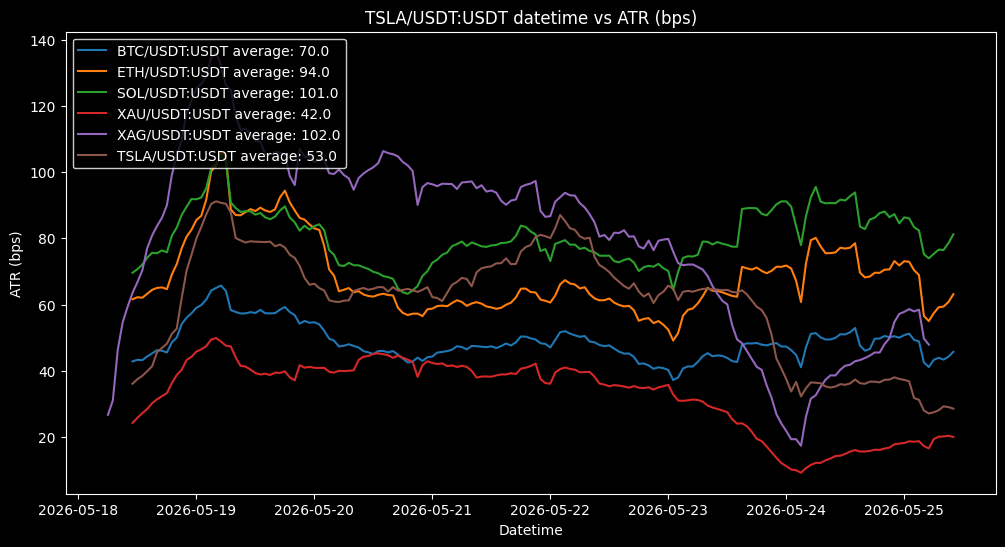

In [18]:
NUM_DAYS = 24*7
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

colors = plt.cm.tab10(range(len(tickers)))

for i, ticker in enumerate(tickers):
    pd_candles = all_candles_w_ta[ticker]
    selected = pd_candles.iloc[-NUM_DAYS:]
    ax1.set_xlabel('Datetime', color='white')
    ax1.set_ylabel('ATR (bps)', color='white')
    ax1.plot(selected['datetime'], selected['atr_bps'], color=colors[i], label=f"{ticker} average: {round(pd_candles['atr_bps'].mean(),0)}")
    ax1.tick_params(axis='y', colors='white')
    ax1.tick_params(axis='x', colors='white')
    ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

plt.title(f'{ticker} datetime vs ATR (bps)')
plt.show()